Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
# Decidimos fixar as sementes aleatórias (seeds) para garantir que os resultados
# (pesos iniciais, dropout, data augmentation e amostras finais) sejam 100%
# reprodutíveis toda vez que este notebook for executado.
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED) # Trava a semente global do Keras

1. Carregamento e Pré-processamento dos Dados



In [2]:
# Mapeamento das classes do CIFAR-10 para facilitar a plotagem dos resultados
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

print("Carregando o dataset CIFAR-10...")
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# As imagens originais são 32x32 com 3 canais (RGB).
# Optamos por normalizar os pixels para o intervalo [0, 1] para acelerar
# e estabilizar a convergência do Gradiente Descendente durante o treino.
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Aqui estamos convertendo os rótulos numéricos para o formato one-hot encoding,
# que é a estrutura esperada pela função de perda categorical_crossentropy
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

Carregando o dataset CIFAR-10...


 1.1 Arquitetura da CNN

In [3]:
# Decidimos intercalar camadas convolucionais com pooling e regularização
# para extrair hierarquias de características da imagem sem fazer sobreajuste (overfitting).
model = keras.Sequential([
    # O primeiro bloco é focado na extração de features de baixo nível como bordas, linhas e contrastes
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(), # Incluímos para estabilizar as ativações e acelerar o treino
    layers.MaxPooling2D((2, 2)), # Reduzimos a dimensionalidade para ganhar invariância espacial
    layers.Dropout(0.25),        # Dropout leve no começo para evitar dependência de pixels específicos

    # No segundo bloco tem foco na extração de features de mais alto nível, exemplo, as texturas e as formas parciais
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Transição das feature maps para a rede neural densa final (MLP)
    layers.Flatten(),            # Achatamento da matriz resultante em um vetor 1D

    # Camadas Densas de Classificação
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),         # Optamos por um Dropout agressivo (50%) na camada densa, onde o risco de decorar os dados é maior
    layers.Dense(10, activation='softmax') # Saída com 10 neurônios (um por classe) em distribuição de probabilidade
])

# Escolhemos o otimizador Adam com a taxa de aprendizado padrão (0.001)
# por ele ter uma convergência geralmente melhor e mais rápida que o SGD clássico neste dataset.
optimizer = keras.optimizers.Adam(learning_rate=0.001)

model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2.1 Treinamento da **Rede**

In [4]:
print("Iniciando o treinamento da CNN")
history = model.fit(x_train, y_train_cat,
                    epochs=20,
                    batch_size=64,
                    validation_data=(x_test, y_test_cat),
                    verbose=1)

Iniciando o treinamento da CNN
Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.3848 - loss: 1.9058 - val_accuracy: 0.5504 - val_loss: 1.2695
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5749 - loss: 1.1965 - val_accuracy: 0.6462 - val_loss: 1.0193
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6259 - loss: 1.0676 - val_accuracy: 0.6220 - val_loss: 1.0835
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6529 - loss: 0.9900 - val_accuracy: 0.6955 - val_loss: 0.8928
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6744 - loss: 0.9353 - val_accuracy: 0.6371 - val_loss: 1.0448
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6874 - loss: 0.8954 - val_accuracy: 0.7081 - val_loss: 0.8620
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7022 - loss: 0.8533 - val_accuracy: 0.7042 - val_loss: 0.8592
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7111 

3.1 Avaliação e Gráficos

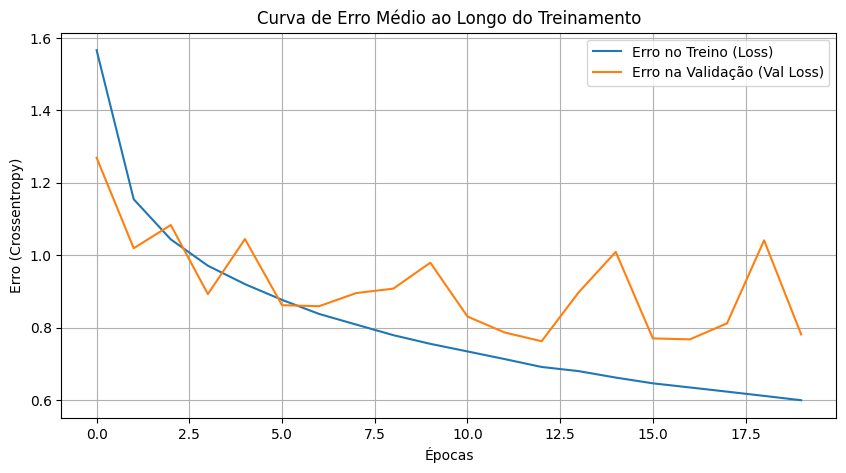

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


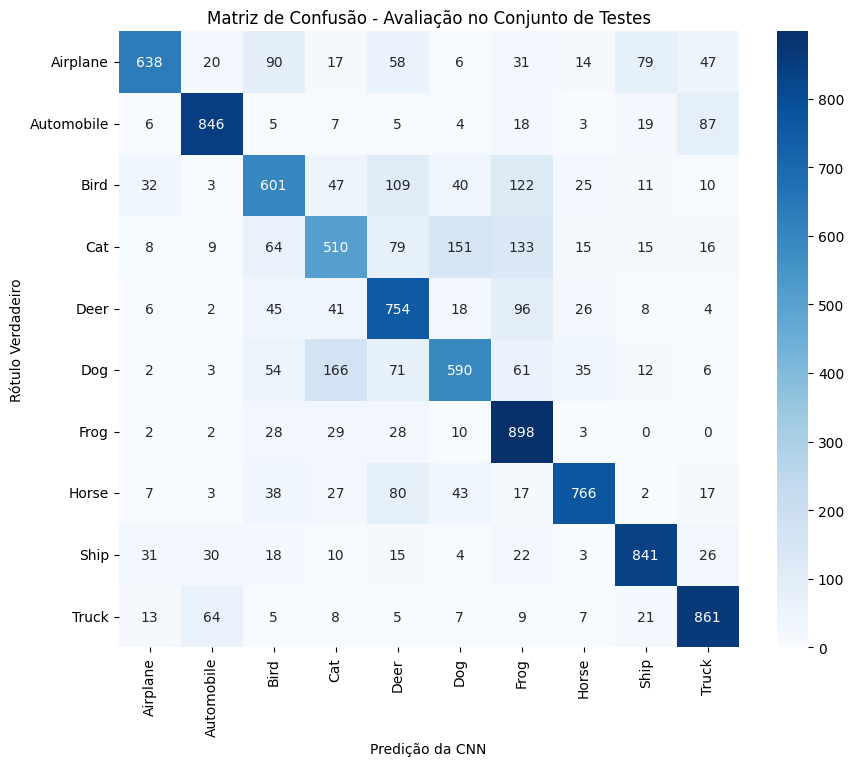


Analisando 5 amostras do conjunto de testes:


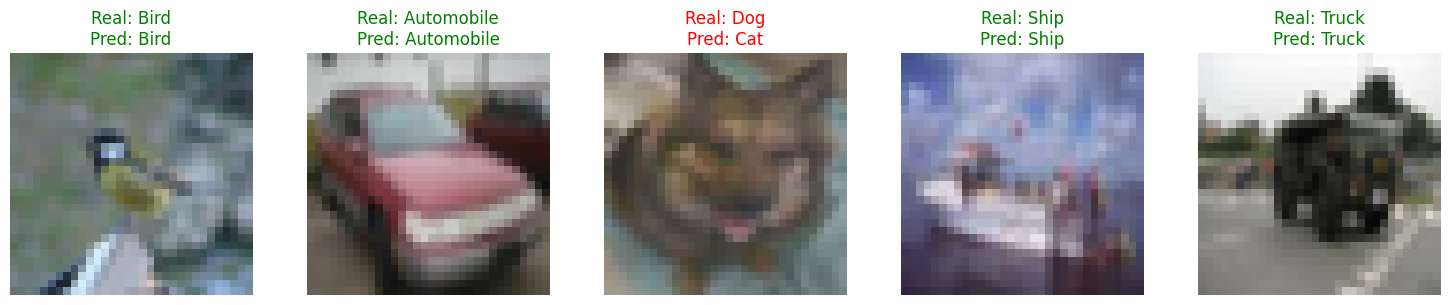

In [5]:
# Plotando a Curva de Erro Médio (Loss) pedida no enunciado
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Erro no Treino (Loss)')
plt.plot(history.history['val_loss'], label='Erro na Validação (Val Loss)')
plt.title('Curva de Erro Médio ao Longo do Treinamento')
plt.xlabel('Épocas')
plt.ylabel('Erro (Crossentropy)')
plt.legend()
plt.grid(True)
plt.show()

# Gerando as predições no conjunto de teste para montarmos a Matriz de Confusão
y_pred_probs = model.predict(x_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Gerando e formatando a Matriz de Confusão
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusão - Avaliação no Conjunto de Testes')
plt.ylabel('Rótulo Verdadeiro')
plt.xlabel('Predição da CNN')
plt.show()

# Análise Qualitativa: Visualização de 5 amostras aleatórias para apresentação
print("\nAnalisando 5 amostras do conjunto de testes:")
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
indices = np.random.choice(len(x_test), 5, replace=False)

for i, idx in enumerate(indices):
    img = x_test[idx]
    true_label = class_names[y_test[idx][0]]
    pred_label = class_names[y_pred_classes[idx]]

    axes[i].imshow(img)
    axes[i].axis('off')
    color = 'green' if true_label == pred_label else 'red'
    axes[i].set_title(f"Real: {true_label}\nPred: {pred_label}", color=color)

plt.tight_layout()
plt.show()

# Segundo Modelo de Resolução

1.2 Data Augmentation Integrado

In [6]:
# Decidimos implementar o Data Augmentation nativamente via Keras.
# Essas distorções ocorrem apenas durante o treinamento, forçando a rede a desenvolver
# invariância espacial verdadeira, o que ataca diretamente o problema de overfitting.
data_augmentation = keras.Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.1),
  layers.RandomZoom(0.1),
])

2.2 Arquitetura da CNN

In [7]:
model = keras.Sequential([
    keras.Input(shape=(32, 32, 3)),
    data_augmentation, # O aumento de dados atua como primeira etapa dinâmica

    # No bloco 1 optamos por duas convoluções seguidas para expandir o campo receptivo
    # antes do downsampling, permitindo melhor extração de bordas e texturas locais.
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)), # Realiza a redução espacial (downsampling)
    layers.Dropout(0.25),        # Dropout inicial leve

    # No segundo bloco fizemos a extração de formas intermediárias
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.35),        # Aumentamos o Dropout conforme aprofundamos a rede

    # No bloco 3 adicionamos está mudança para que este terceiro bloco tenha 128 filtros para capturar
    # as características mais complexas e abstratas das classes.
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.45),

    # Transição: Achata os mapas de características (feature maps) em um vetor unidimensional
    layers.Flatten(),

    # Camadas Densas (Classificação)
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),         # Dropout rigoroso na camada densa, local de maior risco de sobreajuste
    layers.Dense(10, activation='softmax') # Saída multi-classe
])

# Mantivemos o otimizador Adam pela sua comprovada eficiência no CIFAR-10
optimizer = keras.optimizers.Adam(learning_rate=0.001)

model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

3.2 Treinamento da rede com ajuste de épocas

In [8]:
print("Iniciando o treinamento da CNN")
# Como incluímos a distorção do Data Augmentation, decidimos aumentar o treinamento
# para 40 épocas, dando o tempo necessário para o modelo convergir e generalizar.
history = model.fit(x_train, y_train_cat,
                    epochs=40,
                    batch_size=64,
                    validation_data=(x_test, y_test_cat),
                    verbose=1)

Iniciando o treinamento da CNN
Epoch 1/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 22ms/step - accuracy: 0.3117 - loss: 2.2199 - val_accuracy: 0.4471 - val_loss: 1.6035
Epoch 2/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.4801 - loss: 1.4378 - val_accuracy: 0.4912 - val_loss: 1.4551
Epoch 3/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.5494 - loss: 1.2662 - val_accuracy: 0.5387 - val_loss: 1.3048
Epoch 4/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.5859 - loss: 1.1656 - val_accuracy: 0.5564 - val_loss: 1.2507
Epoch 5/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.6071 - loss: 1.1094 - val_accuracy: 0.6506 - val_loss: 1.0001
Epoch 6/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.6311 - loss: 1.0471 - val_accuracy: 0.6454 - val_loss: 1.0041
Epoch 7/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.6482 - loss: 1.0041 - val_accuracy: 0.6232 - val_loss: 1.0797
Epoch 8/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - acc

4.2 Avaliação e Gráficos

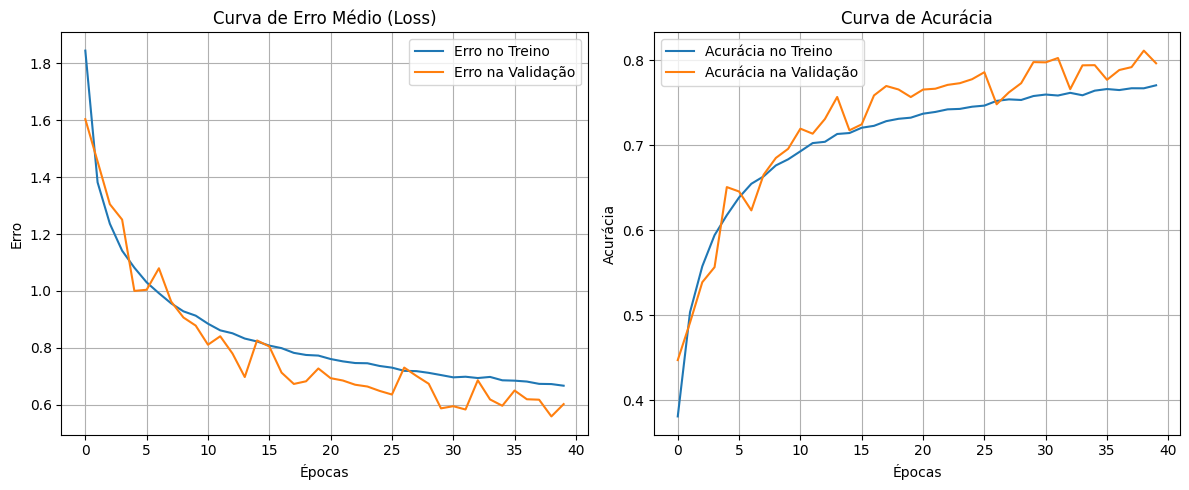

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


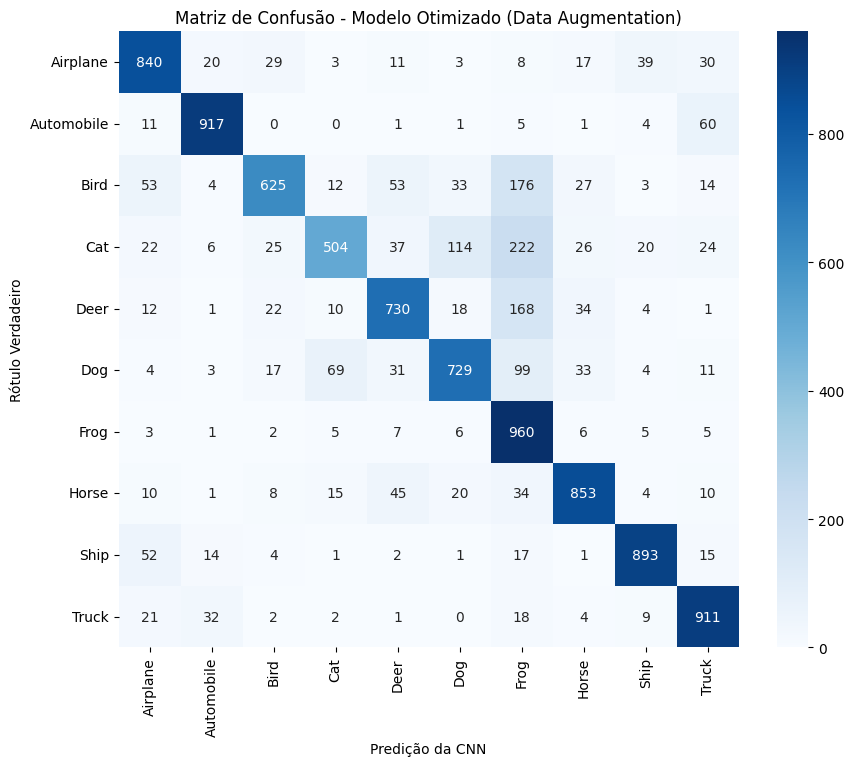


Analisando 5 amostras do conjunto de testes:


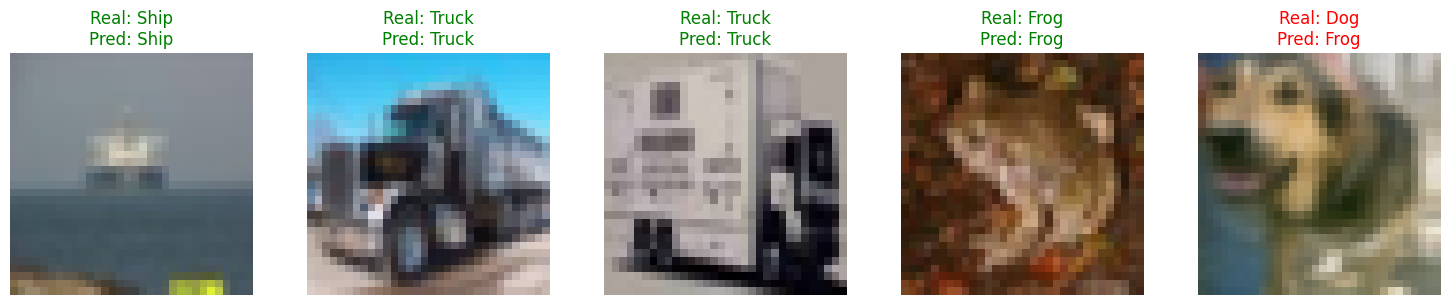

In [9]:
# Decidimos plotar as curvas de Loss e Accuracy lado a lado para melhor visualização do aprendizado
plt.figure(figsize=(12, 5))

# Gráfico 1: Curva de Erro Médio (Loss) pedida no enunciado
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Erro no Treino')
plt.plot(history.history['val_loss'], label='Erro na Validação')
plt.title('Curva de Erro Médio (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Erro')
plt.legend()
plt.grid(True)

# Gráfico 2: Curva de Acurácia
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Acurácia no Treino')
plt.plot(history.history['val_accuracy'], label='Acurácia na Validação')
plt.title('Curva de Acurácia')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Gerando a matriz de confusão sobre o conjunto de teste
y_pred_probs = model.predict(x_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusão - Modelo Otimizado (Data Augmentation)')
plt.ylabel('Rótulo Verdadeiro')
plt.xlabel('Predição da CNN')
plt.show()

print("\nAnalisando 5 amostras do conjunto de testes:")
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
indices = np.random.choice(len(x_test), 5, replace=False)

for i, idx in enumerate(indices):
    img = x_test[idx]
    true_label = class_names[y_test[idx][0]]
    pred_label = class_names[y_pred_classes[idx]]

    axes[i].imshow(img)
    axes[i].axis('off')
    color = 'green' if true_label == pred_label else 'red'
    axes[i].set_title(f"Real: {true_label}\nPred: {pred_label}", color=color)

plt.tight_layout()
plt.show()